# Exploration approfondie de la base d'apprentissage

In [1]:
import pandas as pd
import sys
import os
import warnings

warnings.filterwarnings("ignore")

# On connecte le notebook à tous les fichiers inclus dans le dossier /fonctions
sys.path.insert(0, os.path.abspath("../fonctions"))

%load_ext autoreload
%autoreload 

from eda import *

In [2]:
# Configuration
FILE_PATH = "../data_finale/train.csv"
TARGET    = "market_value_in_eur"
dossier_sauvegarde = "../outputs/eda"

In [3]:
# Chargement de la base de données

df_base = pd.read_csv(FILE_PATH)

In [4]:
print("Types des variables")

analyser_types(df_base)

Types des variables
Analyse des types de variables
Variables numériques   : 152
Variables catégorielles: 4


Analyse des valeurs manquantes
                         nb_missing    pct
contrat_jours_restants         1482  18.24
market_value_in_eur             713   8.78
market_value_in_eur_nor         713   8.78
nation                            2   0.02

Graphique sauvegardé sous : ..\outputs\eda\valeurs_manquantes.png


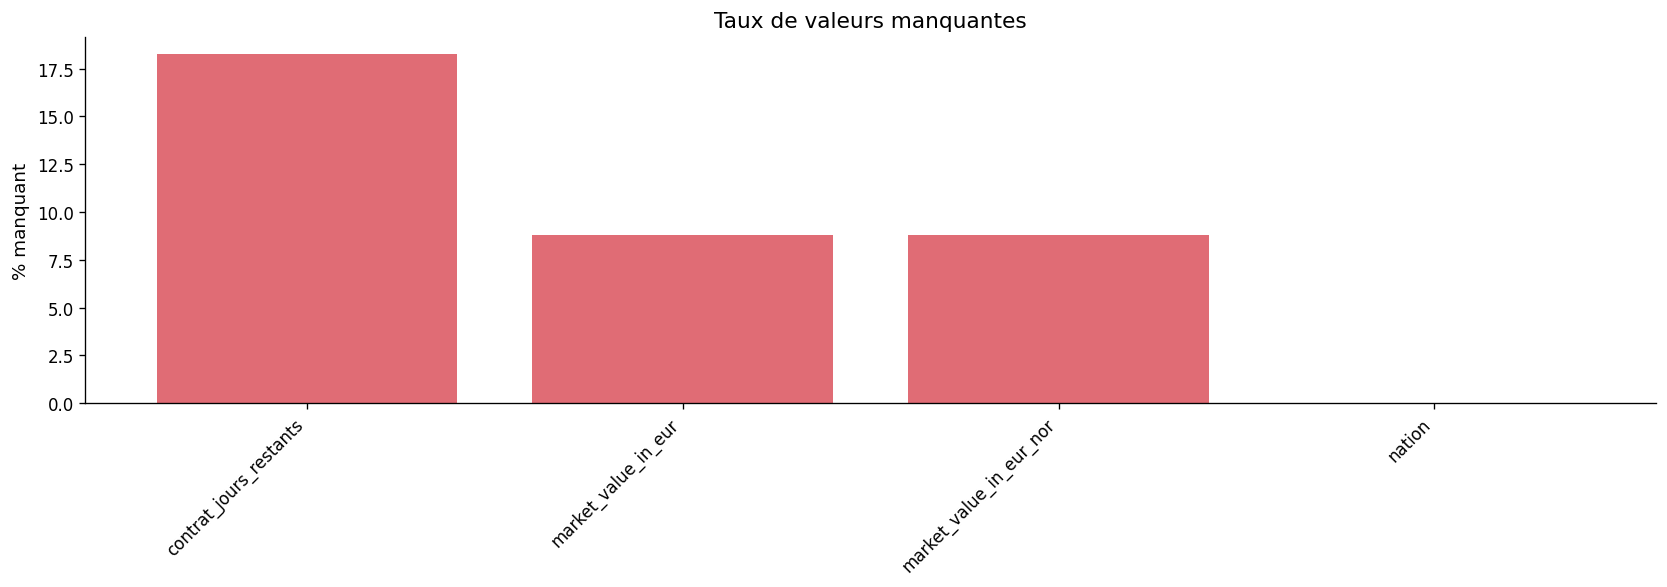

In [5]:
analyser_valeurs_manquantes(df_base, dossier_sauvegarde=dossier_sauvegarde)

Analyse de la variable cible : market_value_in_eur
count          7,412
mean      10,848,867
std       15,543,847
min           50,000
25%        2,000,000
50%        5,000,000
75%       13,250,000
max      180,000,000
Name: market_value_in_eur, dtype: str

Skewness : 3.24
Kurtosis : 15.63

Graphique sauvegardé sous : ..\outputs\eda\distribution_market_value_in_eur.png


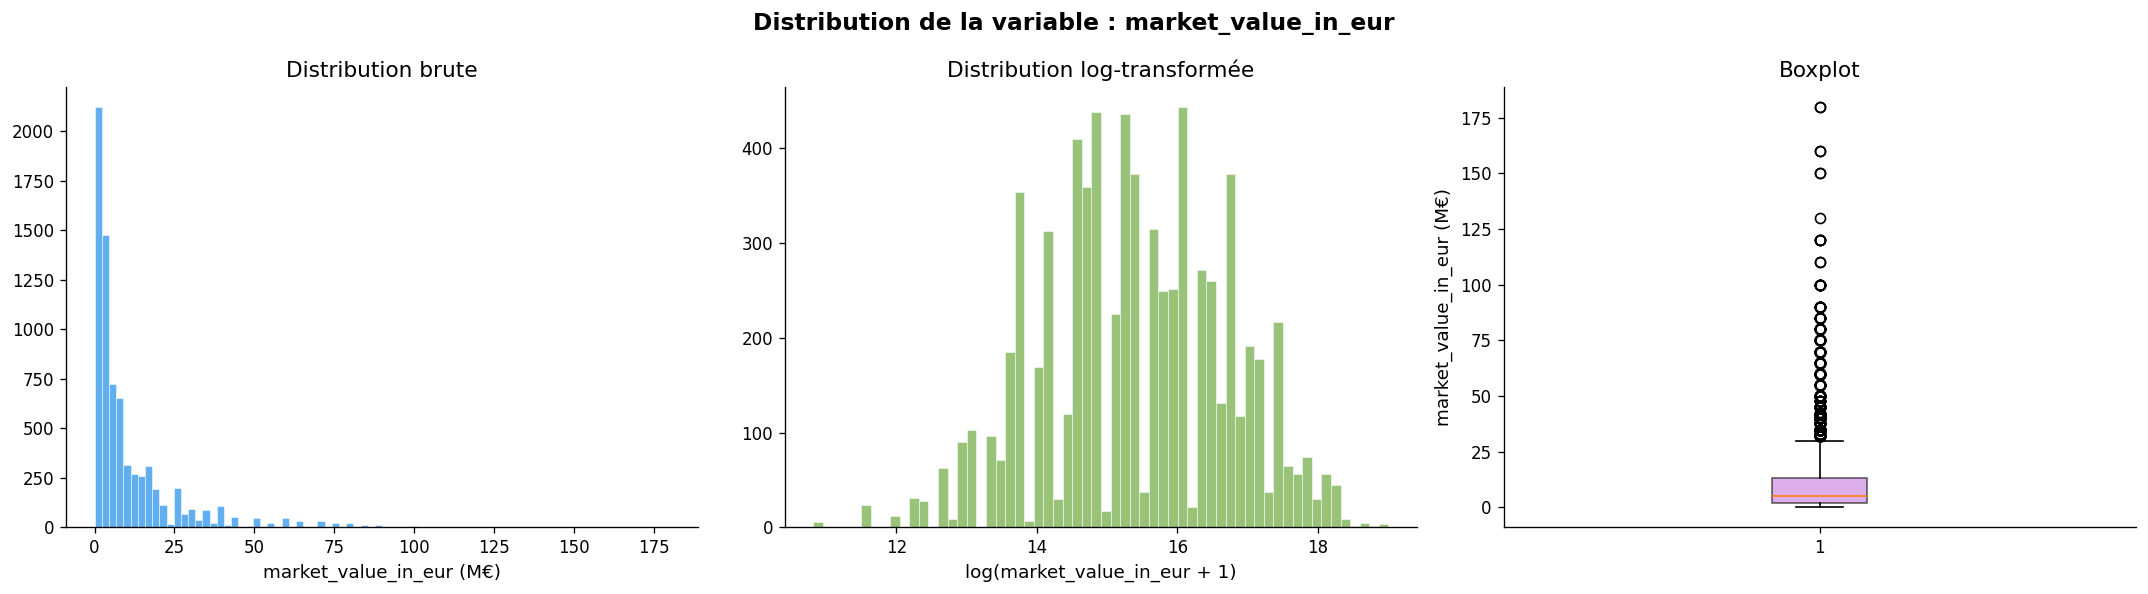

In [6]:
analyser_variable_cible(df_base, target_col=TARGET, dossier_sauvegarde=dossier_sauvegarde)

Distributions des variables numériques clés

Graphique sauvegardé sous : ..\outputs\eda\distributions_variables_numeriques_cles.png


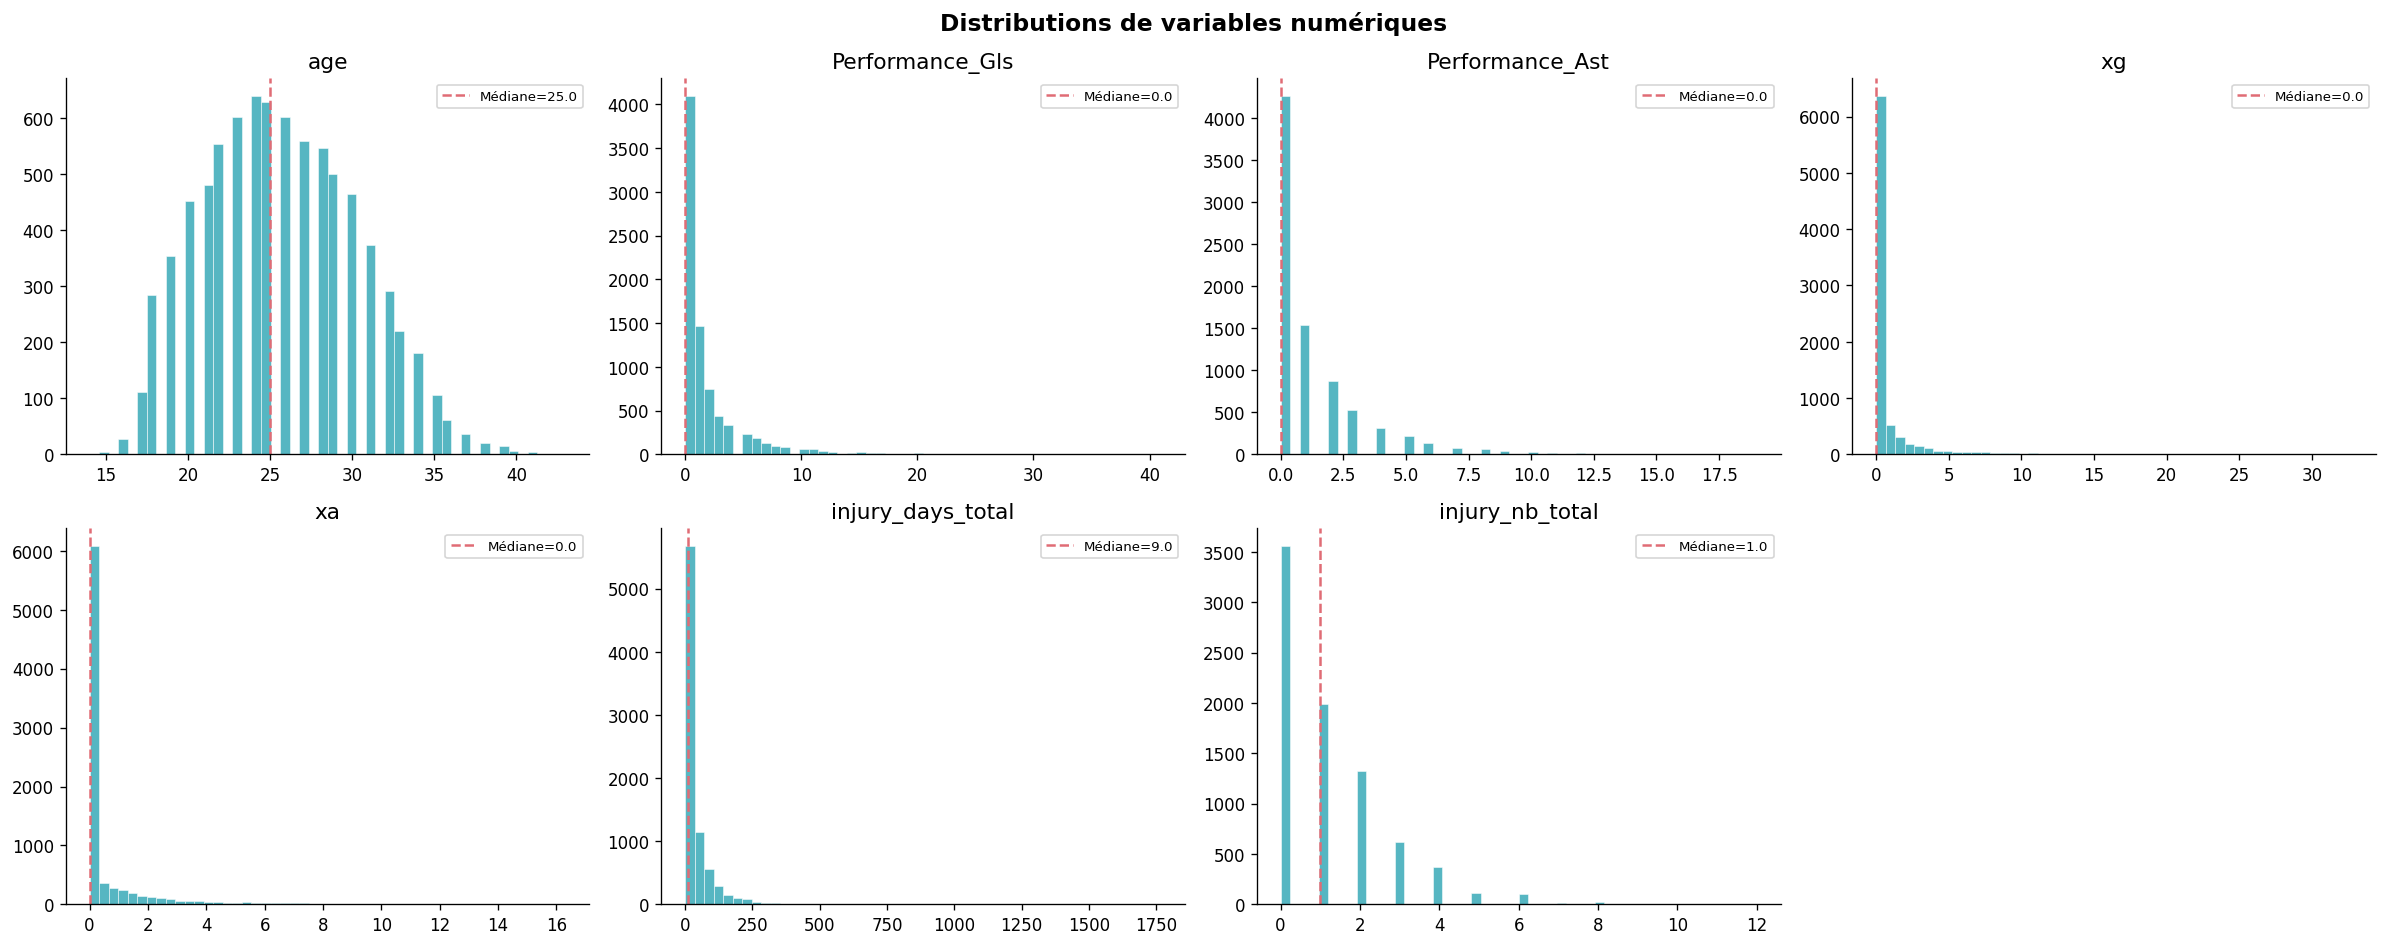

In [7]:
analyser_distributions_numeriques(df_base, cols_a_analyser=None, dossier_sauvegarde=dossier_sauvegarde)

Analyse des variables catégorielles

league (5 modalités encodées) :
ITA-Serie A           1724
ESP-La Liga           1703
FRA-Ligue 1           1685
ENG-Premier League    1550
GER-Bundesliga        1463

players_top_nations.png sauvegardé


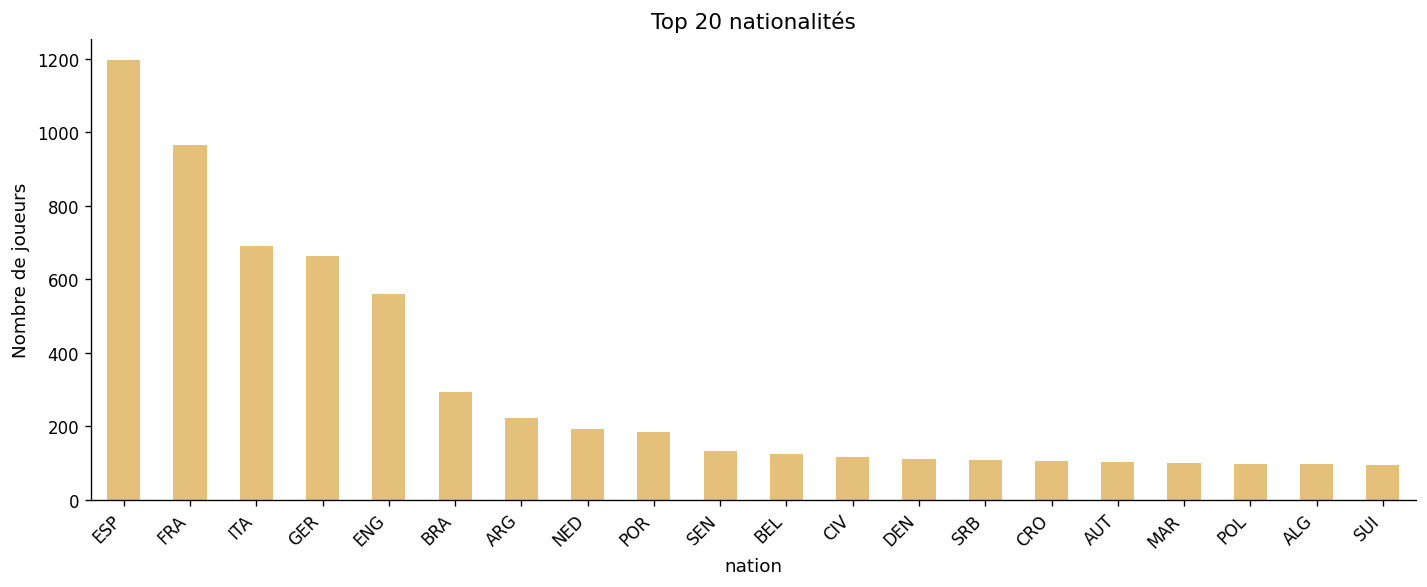

league.png sauvegardé


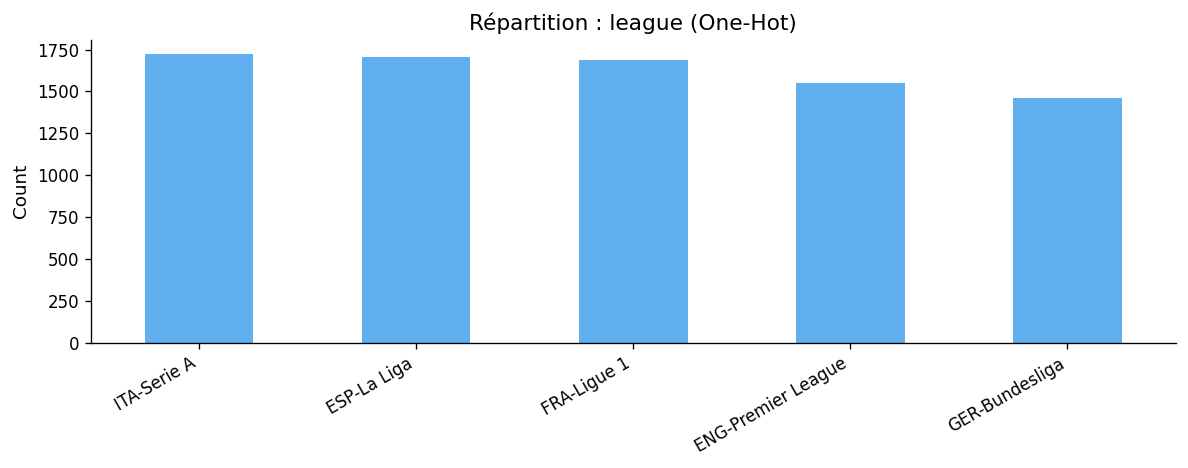

vm_par_league.png sauvegardé


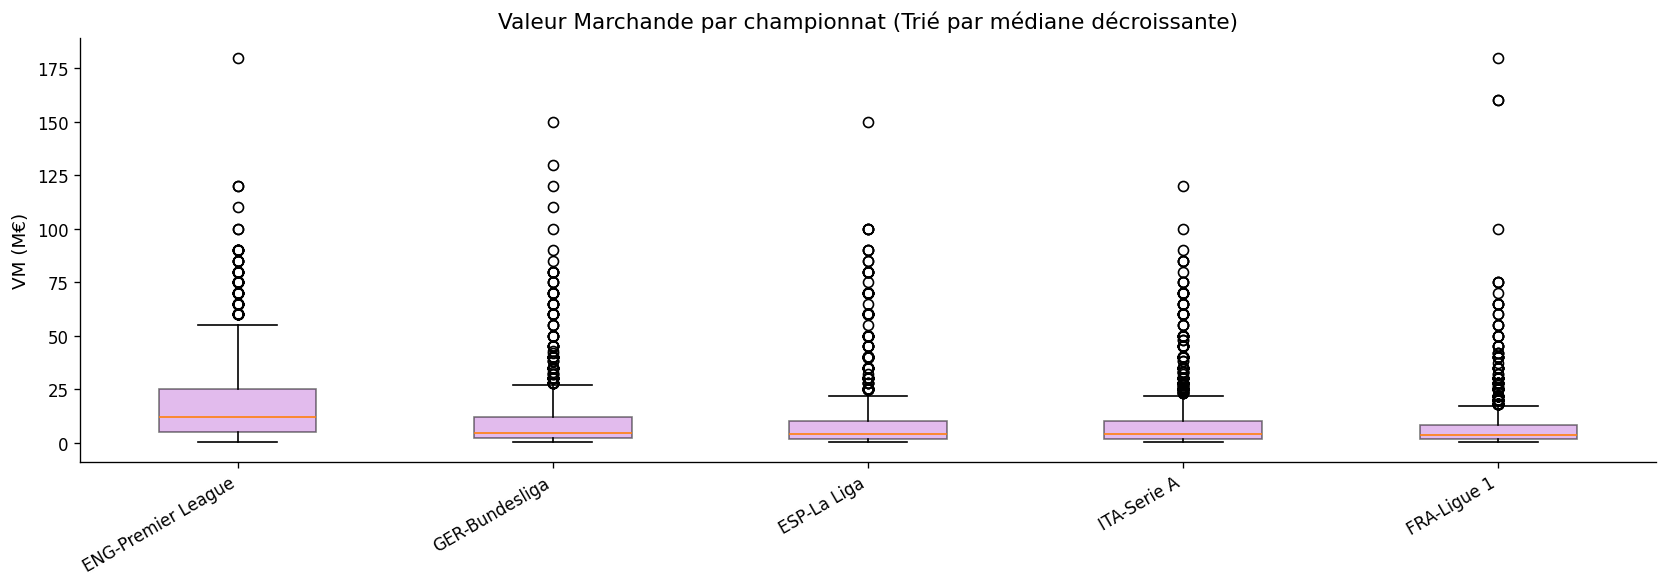

In [8]:
analyser_variables_categorielles(df_base, TARGET, dossier_sauvegarde=dossier_sauvegarde)

In [9]:
analyser_outliers(df_base)

Détection des outliers
         variable  outliers_IQR  pct_IQR  outliers_Zscore  total
              age            12      0.1               12   8125
  Performance_Gls           804      9.9              194   8125
  Performance_Ast           392      4.8              183   8125
               xg          1411     17.4              194   8125
               xa          1511     18.6              238   8125
injury_days_total           662      8.1              140   8125
  injury_nb_total           144      1.8              144   8125


Analyse des corrélations (cible : market_value_in_eur)

Corrélation linéaire avec la cible (variables clés)
                     market_value_in_eur
market_value_in_eur             1.000000
Performance_Gls                 0.478402
Performance_Ast                 0.459407
xg                              0.264273
xa                              0.258049
injury_nb_total                 0.112632
injury_days_total               0.025587
age                            -0.157723

matrice_correlation.png sauvegardé sous : ..\outputs\eda\matrice_correlation.png


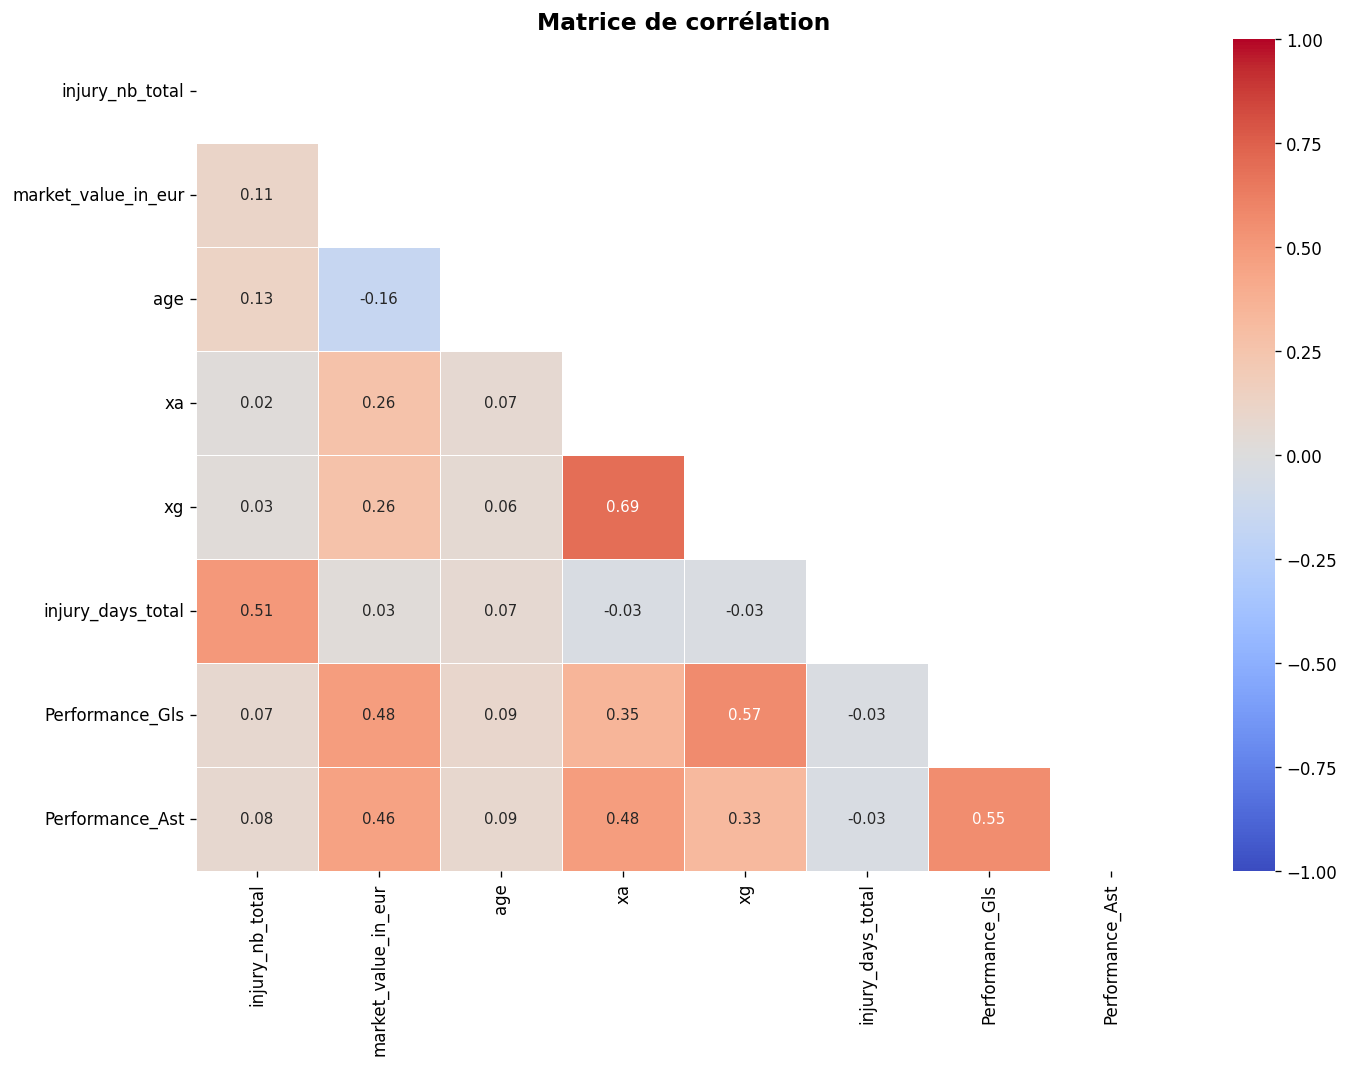


Top 20 des corrélations absolues avec market_value_in_eur (Toutes variables numériques)
market_value_in_eur_nor    1.000000
Team Success_onG           0.576676
Standard_Sh_nor            0.493573
Standard_Sh                0.493573
Standard_SoT_nor           0.485817
Standard_SoT               0.485817
Performance_G-PK           0.483860
Performance_Gls_nor        0.478402
Performance_Gls            0.478402
Performance_Ast_nor        0.459407
Performance_Ast            0.459407
Playing Time_90s           0.386177
Playing Time_Starts_nor    0.384397
Playing Time_Starts        0.384397
Performance_Fld            0.355858
Playing Time_MP            0.355218
Playing Time_MP_nor        0.355218
Team Success_PPM_nor       0.334544
Team Success_PPM           0.334544
Starts_Compl_nor           0.305970


In [10]:
analyser_correlations(df_base, TARGET, cols_cles=None, dossier_sauvegarde=dossier_sauvegarde)

## Segmentation par poste

Analyse du profil médian par poste

Graphique sauvegardé sous : ..\outputs\eda\segmentation_par_poste_profil_poste.png


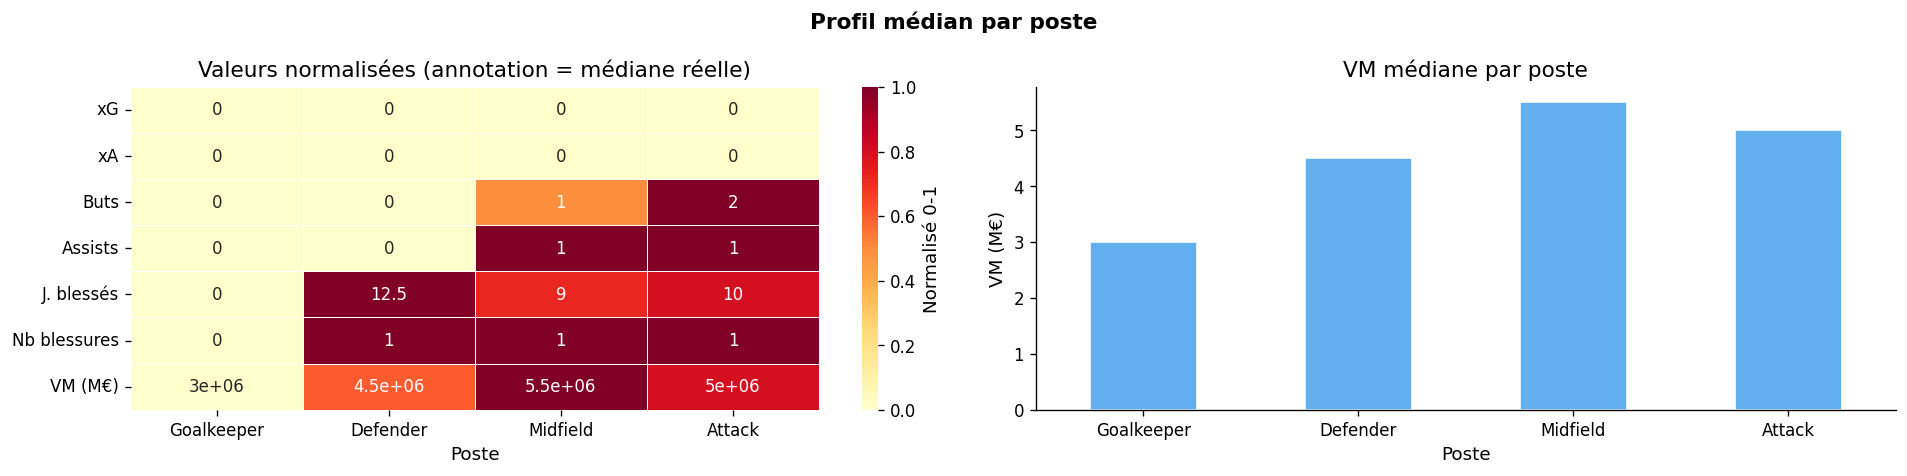

In [11]:
analyser_profil_par_poste(df_base, TARGET, dossier_sauvegarde=dossier_sauvegarde, couleurs_dict=None)

Analyse de la distribution des âges par poste
Graphique sauvegardé sous : ..\outputs\eda\segmentation_par_poste_age_par_poste.png


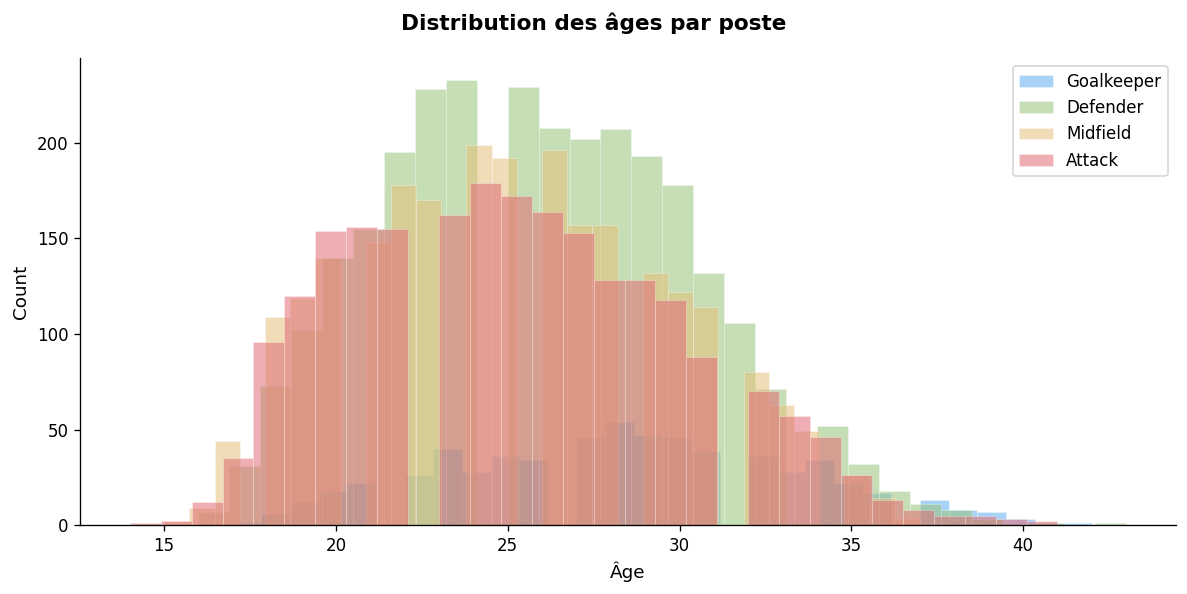


Âge médian par poste
position
Goalkeeper    28.0
Defender      26.0
Midfield      25.0
Attack        25.0


In [12]:
analyser_ages_par_poste(df_base, dossier_sauvegarde=dossier_sauvegarde, liste_couleurs=None)

Analyse croisée : VM médiane par championnat et par poste

Heatmap sauvegardée sous : ..\outputs\eda\feature_engineered_heatmap_league_pos.png


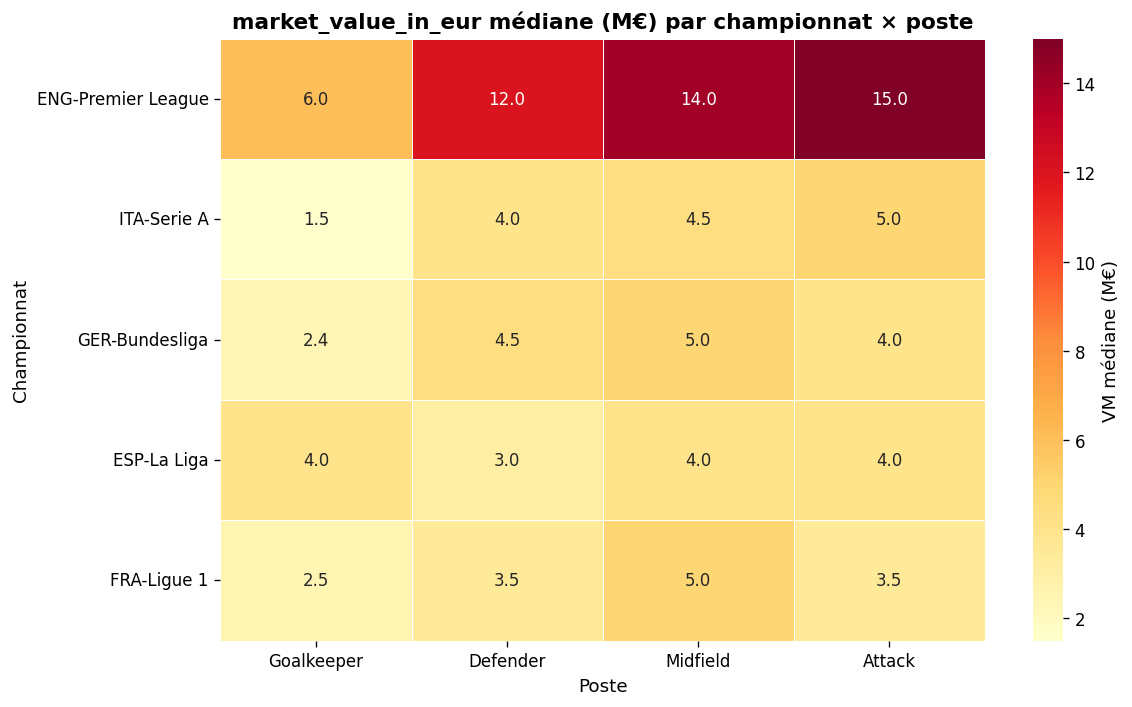

In [13]:
analyser_heatmap_league_poste(df_base, TARGET, dossier_sauvegarde=dossier_sauvegarde)

Analyse de la distribution par championnat

Violin plot sauvegardé sous : ..\outputs\eda\feature_engineered_violin_league.png


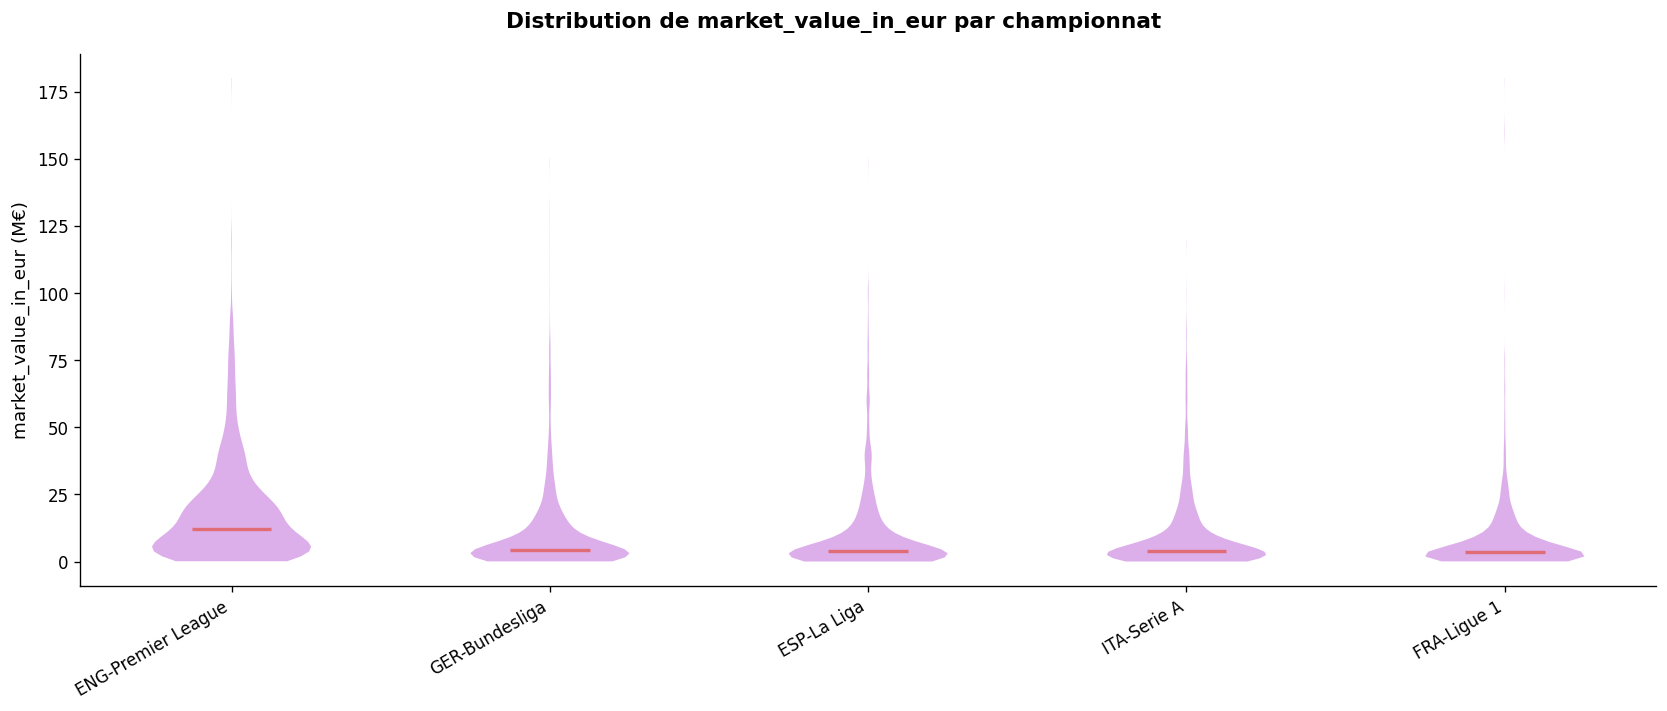

In [14]:
analyser_distribution_violin_league(df_base, TARGET, dossier_sauvegarde=dossier_sauvegarde, couleurs_dict=None)

Analyse des outliers et profils Spécifiques (cible : market_value_in_eur)

Joueurs avec market_value_in_eur ≥ 100M€ : 22 observations

Top 20 des joueurs les plus chers
           player position  age  market_value_in_eur        xg  Performance_Gls  injury_days_total
   Erling Haaland   Attack   22                180.0 32.761400               36               24.0
    Kylian Mbappé   Attack   24                180.0  0.000000               29               14.0
    Kylian Mbappé   Attack   22                160.0  0.000000               27               39.0
    Kylian Mbappé   Attack   23                160.0  0.000000               28               17.0
  Vinicius Júnior   Attack   22                150.0  0.000000               10                8.0
   Erling Haaland   Attack   21                150.0  0.000000               22               99.0
   Erling Haaland   Attack   20                130.0  0.000000               27               10.0
   Victor Osimhen   Attack   24        

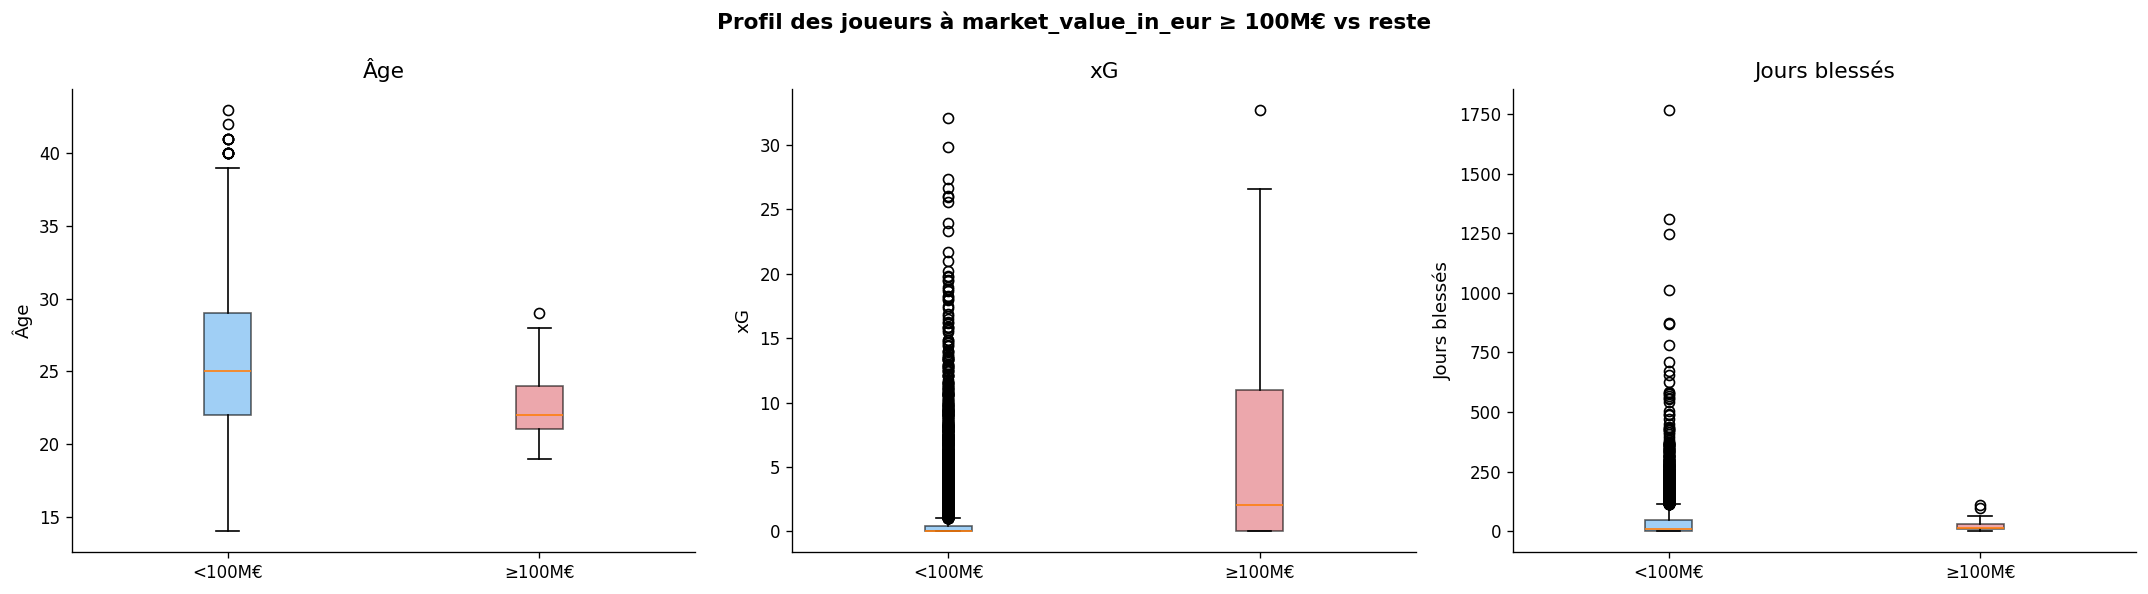

In [15]:
analyser_profil_outliers(df_base, TARGET, dossier_sauvegarde=dossier_sauvegarde, couleurs_dict=None)

In [16]:
verifier_coherence_jours_blessures(df_base)

Contrôle de cohérence : jours de blessures

Cohérence injury_days_total vs somme des composantes (8125/8125 lignes analysées) :
  Cohérents (diff = 0)           : 7,789
  Diff ≤ 1 jour                  : 7,789
  Diff > 1 jour (anomalie)       : 336
  Diff max                       : 1245 jours

Des incohérences ont été détectées. Cela peut provenir de blessures
 qui se chevauchent dans le temps ou de catégories non répertoriées ici.


Analyse de l'évolution temporelle par Saison (cible : market_value_in_eur)

Évolution VM par saison :
             Médiane (M€)  Moyenne (M€)  Nb joueurs
season_year                                        
2020                  5.0     10.578489        2508
2021                  5.0     10.654953        2423
2022                  5.0     11.311568        2481

Graphique sauvegardé sous : ..\outputs\eda\evolution_temporelle.png


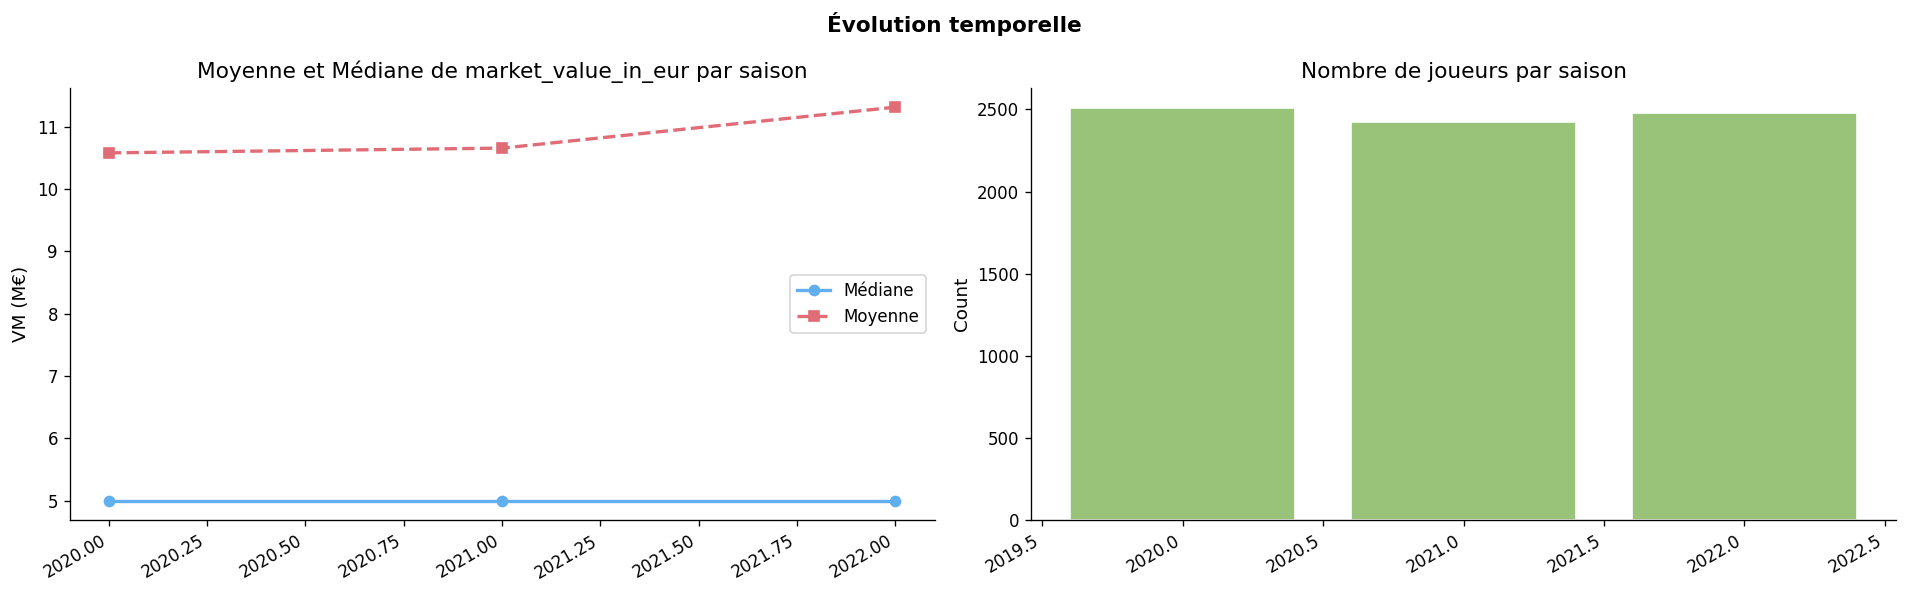

,Médiane (M€),Moyenne (M€),Nb joueurs
season_year,,,
2020,5.0,10.578489,2508
2021,5.0,10.654953,2423
2022,5.0,11.311568,2481


In [17]:
analyser_evolution_temporelle_saison(df_base, TARGET, dossier_sauvegarde=dossier_sauvegarde, couleurs_dict=None)

Démarrage de l'analyse du cycle de vie financier...
8123 observations valides trouvées pour l'analyse graphique.


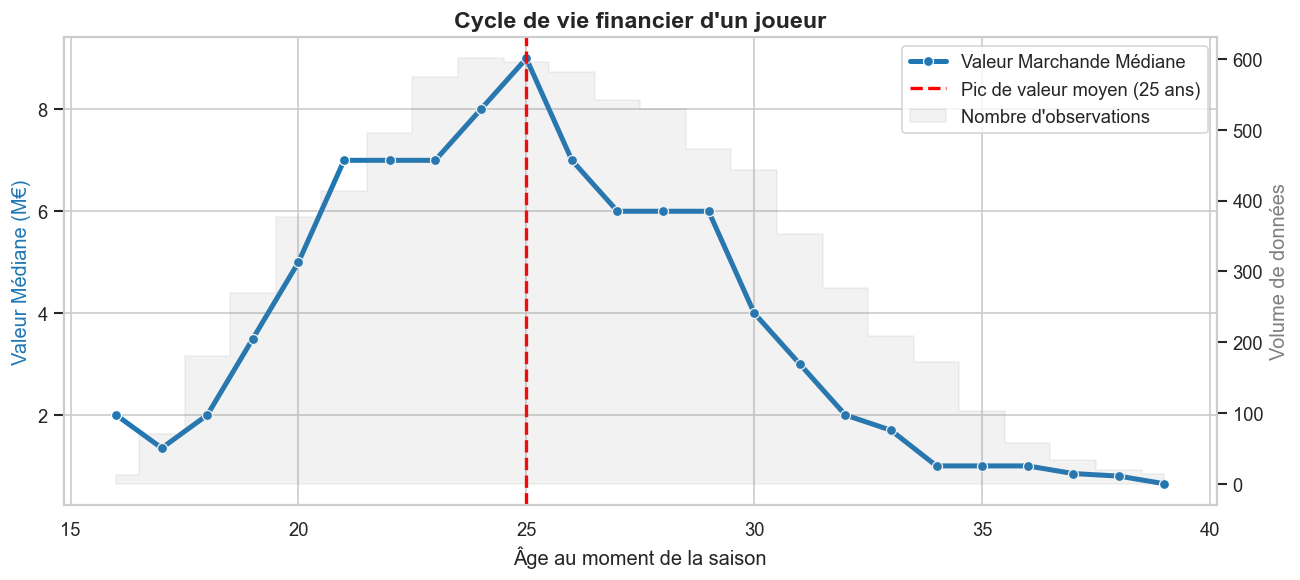


Graphique généré avec succès.


In [18]:
# Application de la fonction
df_base = analyser_cycle_vie_financier(df_base)

Démarrage de l'analyse de distribution des prix...
5 championnats détectés et ordonnés pour l'affichage.


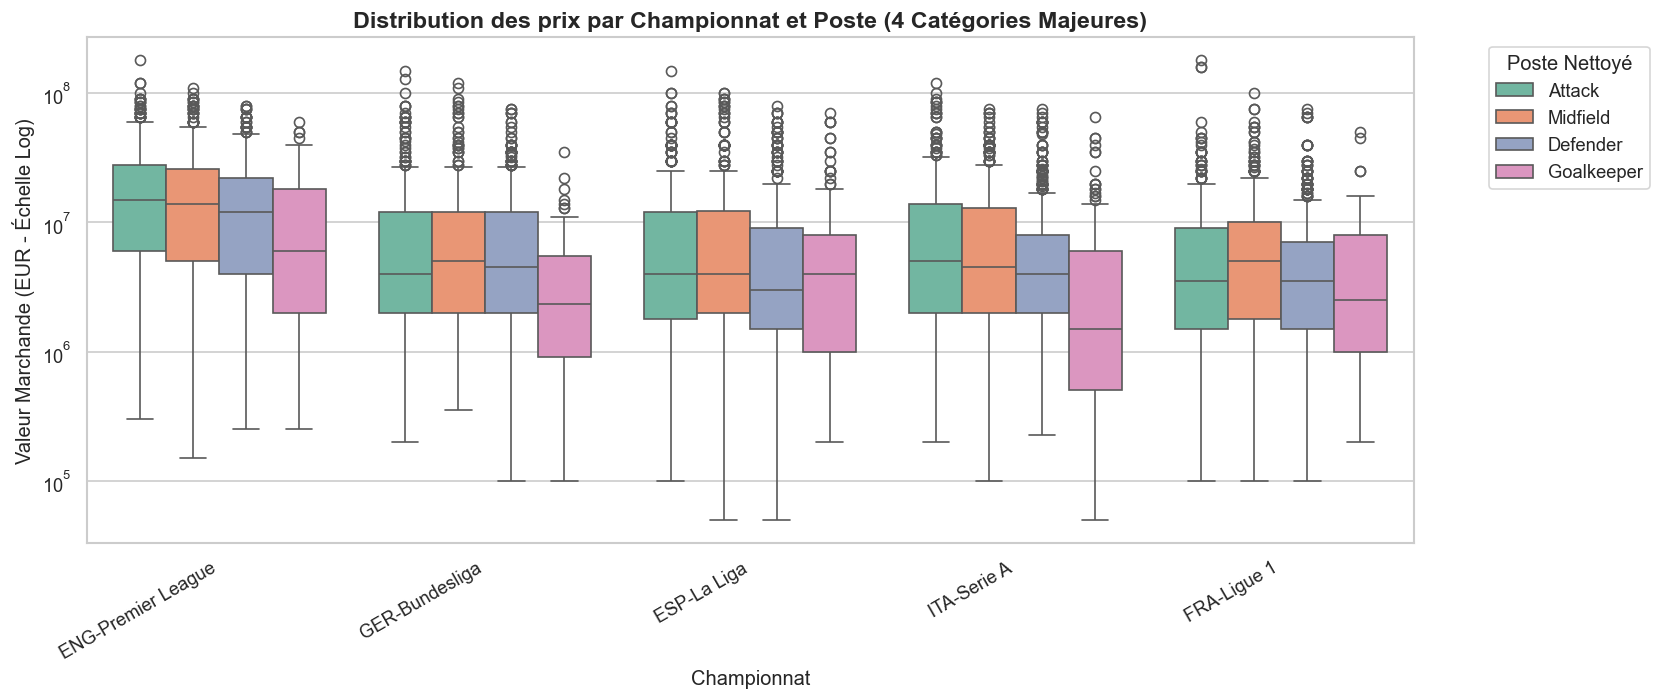


Boxplot généré avec succès.


In [19]:
analyser_distribution_prix_ligue_poste(df_base)

In [20]:
# On détecte les colinéarités
colinearites = detecter_top_colinearites(df_base, top_n=30)

# On affiche le tableau
display(colinearites)

Extraction du Top 30 des colinéarités (hors variables normalisées)...


,Variable_A,Variable_B,Correlation
0,Playing Time_90s,Playing Time_Starts,0.994
1,Performance_G-PK,Performance_Gls,0.978
2,Performance_L,Performance_GA,0.974
3,Performance_Saves,Performance_GA,0.971
4,Performance_PKatt,Performance_PK,0.969
5,pos_GK,Performance_Save%,0.967
6,injury_musculaire_nb_m,injury_musculaire_nb_d,0.960
7,Standard_SoT,Standard_Sh,0.958
8,injury_cheville_pied_nb_m,injury_cheville_pied_nb_d,0.954
9,injury_genou_nb_m,injury_genou_nb_d,0.954


In [21]:
df_base

,player,team,nation,age,Playing Time_MP,Playing Time_Starts,Playing Time_90s,Performance_Gls,Performance_Ast,Performance_G-PK,...,Performance_CS%_nor,Standard_Sh_nor,Standard_SoT_nor,Standard_SoT%_nor,Standard_G/Sh_nor,Standard_G/SoT_nor,Team Success_PPM_nor,xg_nor,xa_nor,xg_buildup_nor
0,Aaron Connolly,Brighton,IRL,20,17,9,8.8,2,1,2,...,0.0,0.117949,0.098901,0.3913,0.09,0.11,0.153043,0.136262,0.009852,0.007741
1,Aaron Connolly,Brighton,IRL,21,4,1,1.7,0,0,0,...,0.0,0.010256,0.000000,0.0000,0.00,0.00,0.217391,0.000000,0.000000,0.000000
2,Aaron Cresswell,West Ham United,ENG,31,36,36,35.2,0,8,0,...,0.0,0.097436,0.043956,0.2105,0.00,0.00,0.314783,0.000000,0.000000,0.000000
3,Aaron Cresswell,West Ham United,ENG,32,31,31,30.3,2,3,2,...,0.0,0.092308,0.043956,0.2222,0.11,0.25,0.252174,0.000000,0.000000,0.000000
4,Aaron Cresswell,West Ham United,ENG,33,28,24,24.8,0,1,0,...,0.0,0.046154,0.010989,0.1111,0.00,0.00,0.193043,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8120,Šime Vrsaljko,Atlético Madrid,CRO,28,9,6,5.8,0,0,0,...,0.0,0.000000,0.000000,0.0000,0.00,0.00,0.445217,0.000000,0.000000,0.000000
8121,Šime Vrsaljko,Atlético Madrid,CRO,29,21,10,10.2,1,2,1,...,0.0,0.020513,0.010989,0.2500,0.25,0.50,0.323478,0.000000,0.000000,0.000000
8122,Ștefan Radu,Lazio,ROU,34,31,30,27.3,0,3,0,...,0.0,0.041026,0.021978,0.2500,0.00,0.00,0.330435,0.000000,0.000000,0.000000
8123,Ștefan Radu,Lazio,ROU,35,10,6,6.2,0,0,0,...,0.0,0.010256,0.010989,0.5000,0.00,0.00,0.243478,0.000000,0.000000,0.000000


Analyse des variables les plus explicatives pour : market_value_in_eur
Filtrage appliqué : Analyse exclusive des Gardiens de but.


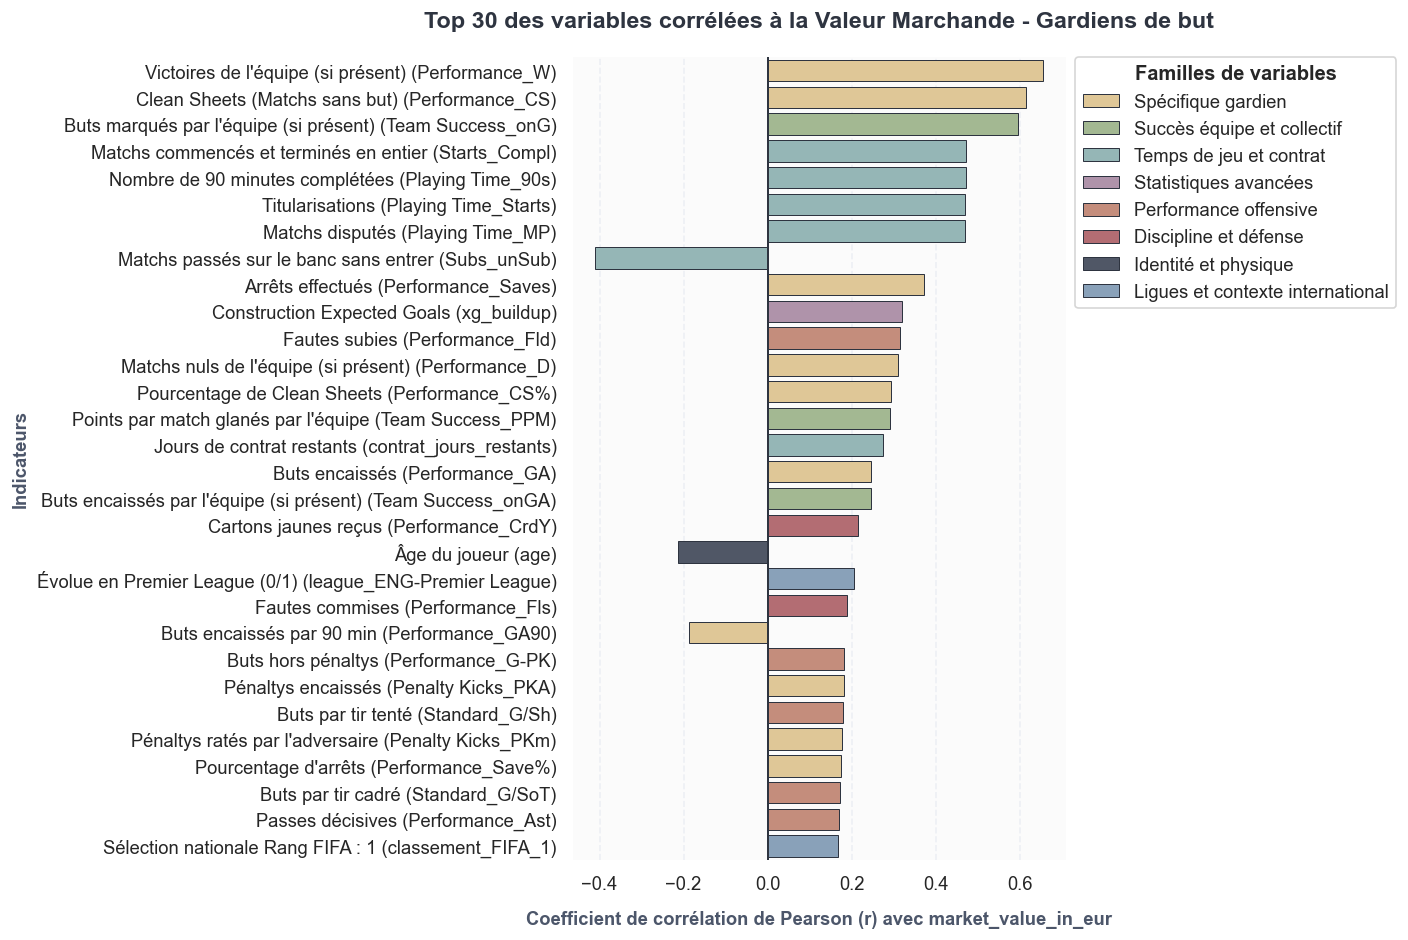

,Variable,Description,Famille,Corr_Cible_Brute
0,Performance_W,Victoires de l'équipe (si présent) (Performanc...,Spécifique gardien,0.656
1,Performance_CS,Clean Sheets (Matchs sans but) (Performance_CS),Spécifique gardien,0.615
2,Team Success_onG,Buts marqués par l'équipe (si présent) (Team S...,Succès équipe et collectif,0.595
3,Starts_Compl,Matchs commencés et terminés en entier (Starts...,Temps de jeu et contrat,0.472
4,Playing Time_90s,Nombre de 90 minutes complétées (Playing Time_...,Temps de jeu et contrat,0.472
5,Playing Time_Starts,Titularisations (Playing Time_Starts),Temps de jeu et contrat,0.471
6,Playing Time_MP,Matchs disputés (Playing Time_MP),Temps de jeu et contrat,0.471
7,Subs_unSub,Matchs passés sur le banc sans entrer (Subs_un...,Temps de jeu et contrat,-0.411
8,Performance_Saves,Arrêts effectués (Performance_Saves),Spécifique gardien,0.372
9,xg_buildup,Construction Expected Goals (xg_buildup),Statistiques avancées,0.319


In [23]:
# On applique la fonction
tableau_importance = analyser_variables_les_plus_explicatives(df_base,
                                                              target_col=TARGET,
                                                              top_n=30,
                                                              afficher_nom_technique=True,
                                                              uniquement_gardiens=True)

# On affiche le tableau propre sous le graphique
display(tableau_importance)